# 🏦 ONCFM — Détection automatique de faux billets

**Organisation Nationale de Lutte Contre le Faux-Monnayage**

---

Dans le cadre de la lutte contre la contrefaçon des billets en euros, 
l'ONCFM met à disposition de ses équipes cet outil de prédiction automatique.

Après numérisation d'un billet (mesures géométriques relevées par scanner),
cette application détermine en quelques secondes si le billet est 
**authentique ou falsifié**, avec une probabilité associée.

**Comment utiliser cet outil :**
1. Placer le fichier CSV des billets à analyser dans le même dossier
2. Exécuter toutes les cellules dans l'ordre (Kernel > Restart & Run All)
   > 💡 **Pour exécuter ce notebook :**  
   > Barre de menu → **Kernel** → **Restart Kernel and Run All Cells...**
4. Lire le tableau de résultats en fin de notebook

**Données attendues :** 6 mesures géométriques par billet  
`diagonal` · `height_left` · `height_right` · `margin_low` · `margin_up` · `length`

<div style="background-color: #bbdefb; padding: 12px; border-radius: 6px; font-weight: bold; font-size: 16px;">
I — Import des librairies - Ne pas modifier 
</div>

In [1]:
import numpy as np
import pandas as pd
import joblib
import datetime
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


print("Librairies chargées ✅")

Librairies chargées ✅


<div style="background-color: #bbdefb; padding: 12px; border-radius: 6px; font-weight: bold; font-size: 16px;">
II — Chargement du modèle - Ne pas modifier
</div>

In [2]:
pipeline = joblib.load("pipeline_detection_faux_billets.pkl")

print("Modèle chargé ✅")

Modèle chargé ✅


<div style="background-color: #bbdefb; padding: 12px; border-radius: 6px; font-weight: bold; font-size: 16px;">
III — Chargement du fichier à analyser
</div>

<div style="background-color:#FFF3CD; border-left:6px solid #FFA500; padding:12px; border-radius:4px;">
<b>⚠️ ACTION REQUISE — À lire avant d'exécuter</b><br><br>
1. Placer le fichier CSV à analyser dans le <b>même dossier</b> que ce notebook<br>
2. Dans la cellule ci-dessous, remplacer uniquement <code>"billets_production.csv"</code> par le nom de votre fichier<br><br>
<b>📋 Format obligatoire du fichier CSV :</b><br>
Le fichier doit contenir exactement ces 7 colonnes :<br>
<code>id · diagonal · height_left · height_right · margin_low · margin_up · length</code><br><br>
<b>✔️ Avant de lancer l'analyse, vérifier que le fichier :</b><br>
— ne contient pas de lignes en double<br>
— ne contient pas de valeurs manquantes 
— contient uniquement des valeurs numériques dans les colonnes géométriques<br>
— fichier non vide <i>→ erreur critique</i><br>
<b>🚨 En cas d'anomalie détectée, un message d'erreur s'affichera et l'analyse sera interrompue.<br>
Corriger le fichier CSV puis relancer le notebook via Kernel → Restart Kernel and Run All Cells.</b>
</div>

In [3]:
#️⃣♦️  Modifier uniquement le nom du fichier si nécessaire 

df_prod = pd.read_csv("billets_production.csv")

print(f"Fichier chargé : {len(df_prod)} billet(s) à analyser ✅")
display(df_prod)

Fichier chargé : 5 billet(s) à analyser ✅


,diagonal,height_left,height_right,margin_low,margin_up,length,id
0,171.76,104.01,103.54,5.21,3.30,111.42,A_1
1,171.87,104.17,104.13,6.00,3.31,112.09,A_2
2,172.00,104.58,104.29,4.99,3.39,111.57,A_3
3,172.49,104.55,104.34,4.44,3.03,113.20,A_4
4,171.65,103.63,103.56,3.77,3.16,113.33,A_5


<div style="background-color:#F4F6F7; border-left:6px solid #808B96; padding:12px; border-radius:4px; font-size:14px;">
<b>IV bis — Contrôle qualité du fichier - Ne pas modifier</b><br>
<span style="color:#5D6D7E;">Cette cellule vérifie automatiquement la conformité du fichier avant analyse.</span>
</div>

In [4]:
#️⃣♦️ Contrôle qualité du fichier donné

print("=" * 55)
print("   CONTRÔLE QUALITÉ DU FICHIER")
print("=" * 55)

# ── 1. Fichier vide ──
if len(df_prod) == 0:
    print("ERREUR : le fichier est vide — arrêt de l'analyse")
    raise ValueError("Fichier vide")
else:
    print(f"Nombre de billets à analyser : {len(df_prod)} ✓")

# ── 2. Colonnes manquantes ──
colonnes_attendues = ["diagonal", "height_left", "height_right",
                      "margin_low", "margin_up", "length", "id"]
manquantes = [c for c in colonnes_attendues if c not in df_prod.columns]
if manquantes:
    print(f"ERREUR : colonnes manquantes → {manquantes}")
    raise ValueError("Colonnes manquantes")
else:
    print("Colonnes : OK ✓")

# ── 3. Doublons ──
nb_doublons = df_prod.duplicated().sum()
if nb_doublons > 0:
    print(f"ATTENTION : {nb_doublons} doublon(s) détecté(s) — suppression automatique")
    df_prod = df_prod.drop_duplicates().reset_index(drop=True)
else:
    print("Doublons : aucun ✓")

# ── 4. Valeurs manquantes ──
cols_geo = ["diagonal", "height_left", "height_right",
            "margin_low", "margin_up", "length"]
nb_nan = df_prod[cols_geo].isna().sum().sum()
if nb_nan > 0:
    print(f"ERREUR : {nb_nan} valeur(s) manquante(s) détectée(s) — analyse interrompue")
    print("Ce script requiert un fichier complet sans valeurs manquantes.")
    raise ValueError("Valeurs manquantes détectées")
else:
    print("Valeurs manquantes : aucune ✓")

# ── 5. Valeurs numériques ──
try:
    df_prod[cols_geo].astype(float)
    print("Format numérique : OK ✓")
except ValueError:
    print("ERREUR : valeurs non numériques détectées dans les colonnes géométriques")
    raise

# ── 6. Plages réalistes ──
limites = {
    "diagonal":     (160, 180),
    "height_left":  (100, 108),
    "height_right": (100, 108),
    "margin_low":   (2, 8),
    "margin_up":    (2, 6),
    "length":       (107, 117)
}
anomalies = []
for col, (mini, maxi) in limites.items():
    hors = df_prod[(df_prod[col] < mini) | (df_prod[col] > maxi)]
    if len(hors) > 0:
        anomalies.append(f"{col} : {len(hors)} valeur(s) hors plage [{mini}-{maxi}]")

if anomalies:
    print("ATTENTION : valeurs hors plage détectées →")
    for a in anomalies:
        print(f"   {a}")
else:
    print("Plages de valeurs : OK ✓")

print("=" * 55)
print(f"Contrôle effectué le : {datetime.datetime.now().strftime('%d/%m/%Y à %H:%M:%S')}")
print("=" * 55)

   CONTRÔLE QUALITÉ DU FICHIER
Nombre de billets à analyser : 5 ✓
Colonnes : OK ✓
Doublons : aucun ✓
Valeurs manquantes : aucune ✓
Format numérique : OK ✓
Plages de valeurs : OK ✓
Contrôle effectué le : 17/06/2026 à 11:54:30


<div style="background-color: #bbdefb; padding: 12px; border-radius: 6px; font-weight: bold; font-size: 16px;">
V — Prédiction - Ne pas modifier
</div>

In [5]:
FEATURES = ["diagonal", "height_left", "height_right",
            "margin_low", "margin_up", "length"]

predictions  = pipeline.predict(df_prod[FEATURES])
probabilites = pipeline.predict_proba(df_prod[FEATURES])[:, 0]  # P(faux)

df_prod["nature"]         = pd.Series(predictions).map({1: "VRAI", 0: "FAUX"})
df_prod["proba_faux (%)"] = (probabilites * 100).round(2)

print("Prédictions effectuées ✅ ")

Prédictions effectuées ✅ 


<div style="background-color:#D4EDDA; border-left:6px solid #28A745; padding:12px; border-radius:4px;">
<b> VI — Résultats de l'analyse - Ne pas modifier </b><br>
Le tableau ci-dessous présente la nature de chaque billet analysé ainsi que la probabilité associée.
</div>

In [6]:
print("=" * 55)
print("   RÉSULTATS — DÉTECTION DES FAUX BILLETS (ONCFM)")
print("=" * 55)

cols_affichage = ["id", "nature", "proba_faux (%)"]
display(df_prod[cols_affichage])

print()
nb_faux  = (predictions == 0).sum()
nb_vrais = (predictions == 1).sum()
print(f" Vrais billets détectés : {nb_vrais}")
print(f" Faux billets détectés  : {nb_faux}")

# ── Zone de doute ──
doutes_df = df_prod[(df_prod["proba_faux (%)"] >= 40) & 
                    (df_prod["proba_faux (%)"] <= 60)]
if len(doutes_df) > 0:
    print()
    print(f" ATTENTION : {len(doutes_df)} billet(s) en zone de doute (40-60%)")
    print(" Verification manuelle recommandee :")
    display(doutes_df[cols_affichage])

print("=" * 55)

   RÉSULTATS — DÉTECTION DES FAUX BILLETS (ONCFM)


,id,nature,proba_faux (%)
0,A_1,FAUX,99.90
1,A_2,FAUX,99.99
2,A_3,FAUX,99.98
3,A_4,VRAI,2.08
4,A_5,VRAI,0.01



 Vrais billets détectés : 2
 Faux billets détectés  : 3


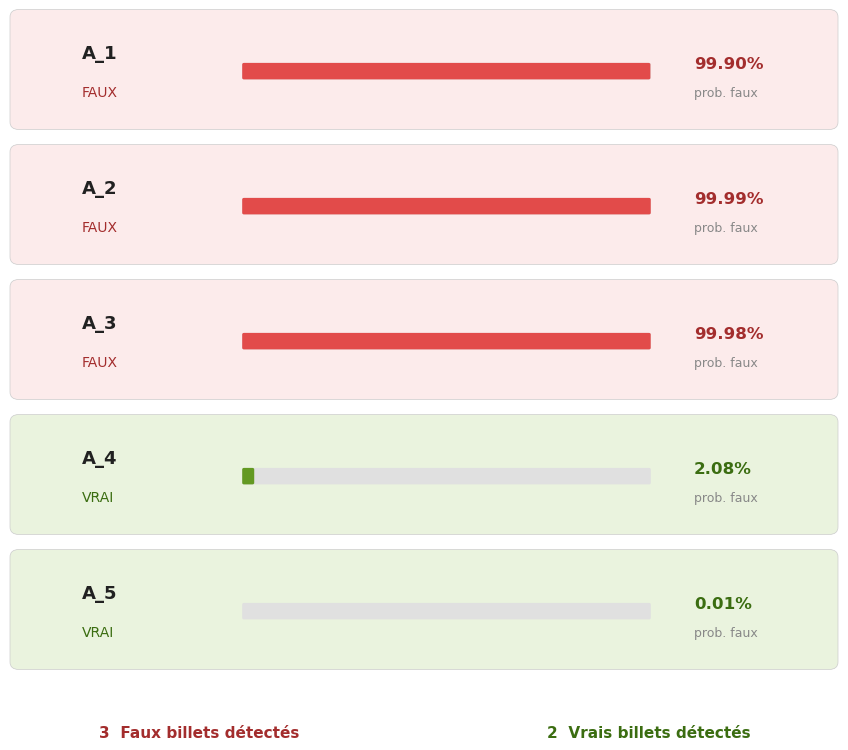

Graphique sauvegarde ✓


In [7]:
#️⃣ ♦️ Visualisation du résultat

billets = []
for _, row in df_prod.iterrows():
    faux = row["nature"] == "FAUX"
    billets.append({
        "id":     row["id"],
        "nature": row["nature"],
        "proba":  row["proba_faux (%)"],
        "faux":   faux
    })

# Détection zone de doute
doutes = [b for b in billets if 40 <= b["proba"] <= 60]

nb_billets = len(billets)
hauteur_extra = 0.15 if doutes else 0
fig, ax = plt.subplots(figsize=(9, 1.2 * nb_billets + 1.5 + hauteur_extra))
fig.patch.set_facecolor("#FFFFFF")
ax.set_visible(False)

card_h   = 0.14
card_gap = 0.04
y_start  = 0.95

for i, b in enumerate(billets):
    y = y_start - i * (card_h + card_gap)
    couleur_fond  = "#FCEBEB" if b["faux"] else "#EAF3DE"
    couleur_texte = "#A32D2D" if b["faux"] else "#3B6D11"
    couleur_barre = "#E24B4A" if b["faux"] else "#639922"

    card = mpatches.FancyBboxPatch(
        (0.05, y - card_h), 0.90, card_h,
        boxstyle="round,pad=0.01",
        linewidth=0.5, edgecolor="#CCCCCC",
        facecolor=couleur_fond,
        transform=fig.transFigure, clip_on=False
    )
    fig.add_artist(card)

    fig.text(0.12, y - card_h * 0.35, b["id"],
             fontsize=13, fontweight="bold", color="#212121",
             transform=fig.transFigure, va="center")

    fig.text(0.12, y - card_h * 0.72, b["nature"],
             fontsize=10, color=couleur_texte,
             transform=fig.transFigure, va="center")

    barre_fond = mpatches.FancyBboxPatch(
        (0.30, y - card_h * 0.58), 0.45, 0.018,
        boxstyle="round,pad=0.002",
        linewidth=0, facecolor="#E0E0E0",
        transform=fig.transFigure, clip_on=False
    )
    fig.add_artist(barre_fond)

    largeur_barre = 0.45 * (b["proba"] / 100)
    if largeur_barre > 0.004:
        barre = mpatches.FancyBboxPatch(
            (0.30, y - card_h * 0.58), largeur_barre, 0.018,
            boxstyle="round,pad=0.002",
            linewidth=0, facecolor=couleur_barre,
            transform=fig.transFigure, clip_on=False
        )
        fig.add_artist(barre)

    fig.text(0.80, y - card_h * 0.45, f"{b['proba']:.2f}%",
             fontsize=12, fontweight="bold", color=couleur_texte,
             transform=fig.transFigure, va="center")

    fig.text(0.80, y - card_h * 0.72, "prob. faux",
             fontsize=9, color="#888888",
             transform=fig.transFigure, va="center")

# ── Zone de doute ──
y_doute = y_start - nb_billets * (card_h + card_gap) - 0.02
if doutes:
    ids_doutes = ", ".join([b["id"] for b in doutes])
    carte_doute = mpatches.FancyBboxPatch(
        (0.05, y_doute - 0.10), 0.90, 0.10,
        boxstyle="round,pad=0.01",
        linewidth=0.5, edgecolor="#FFA500",
        facecolor="#FFF3CD",
        transform=fig.transFigure, clip_on=False
    )
    fig.add_artist(carte_doute)
    fig.text(0.50, y_doute - 0.05,
             f"ATTENTION : billet(s) en zone de doute (40-60%) → {ids_doutes} — verification manuelle recommandee",
             fontsize=9, color="#856404", ha="center",
             transform=fig.transFigure, va="center")
    y_compteurs = y_doute - 0.14
else:
    y_compteurs = y_doute - 0.04

# ── Compteurs résumé ──
nb_faux  = sum(1 for b in billets if b["faux"])
nb_vrais = sum(1 for b in billets if not b["faux"])

fig.text(0.25, y_compteurs, f"{nb_faux}  Faux billets détectés",
         fontsize=11, fontweight="bold", color="#A32D2D",
         transform=fig.transFigure, ha="center")
fig.text(0.75, y_compteurs, f"{nb_vrais}  Vrais billets détectés",
         fontsize=11, fontweight="bold", color="#3B6D11",
         transform=fig.transFigure, ha="center")

plt.savefig("resultats_oncfm.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("Graphique sauvegarde ✓")

<div style="background-color:#F4F6F7; border-left:6px solid #808B96; padding:12px; border-radius:4px; font-size:14px;">
<b>VII — Sauvegarde et bilan - Ne pas modifier</b><br>
<span style="color:#5D6D7E;">Les résultats sont automatiquement sauvegardés dans un fichier CSV horodaté dans le même dossier.</span>
</div>

In [8]:
horodatage  = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
nom_fichier = f"resultats_ONCFM_{horodatage}.csv"

cols_export = ["id", "nature", "proba_faux (%)"]
df_prod[cols_export].to_csv(nom_fichier, index=False, sep=";")

print("=" * 55)
print("   BILAN FINAL — ONCFM")
print("=" * 55)
print(f" Analyse effectuée le  : {datetime.datetime.now().strftime('%d/%m/%Y à %H:%M:%S')}")
print(f" Billets analysés      : {len(df_prod)}")
print(f" Faux détectés         : {(df_prod['nature'] == 'FAUX').sum()}")
print(f" Vrais détectés        : {(df_prod['nature'] == 'VRAI').sum()}")
print(f" Fichier sauvegardé    : {nom_fichier}")
print("=" * 55)

   BILAN FINAL — ONCFM
 Analyse effectuée le  : 17/06/2026 à 11:54:30
 Billets analysés      : 5
 Faux détectés         : 3
 Vrais détectés        : 2
 Fichier sauvegardé    : resultats_ONCFM_20260617_115430.csv
